# Student Placement Prediction

## 1. Problem Statement

The goal of this project is to develop a machine learning model that predicts whether a student will be placed based on academic performance, technical skills, and practical experience.

Universities often want to identify students who may be at risk of not being placed so that they can provide additional training, mentorship, or career guidance.

Using a dataset containing 100,000 student records, this project explores patterns in student performance and builds classification models to predict placement outcomes.

The study also evaluates how different factors such as coding ability, internship experience, and academic performance influence placement probability.

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv(r'C:\Users\User\PyCharmMiscProject\Datasets\student_placement_synthetic.csv')
df.info() # 2


<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   branch                     100000 non-null  str    
 1   college_tier               100000 non-null  str    
 2   cgpa                       100000 non-null  float64
 3   backlogs                   100000 non-null  int64  
 4   coding_skills              100000 non-null  float64
 5   dsa_score                  100000 non-null  float64
 6   aptitude_score             100000 non-null  float64
 7   communication_skills       100000 non-null  float64
 8   ml_knowledge               100000 non-null  float64
 9   system_design              100000 non-null  float64
 10  internships                100000 non-null  int64  
 11  projects_count             100000 non-null  int64  
 12  certifications             100000 non-null  int64  
 13  hackathons                 100000 non-nul

In [62]:
print(f"\nThis is shape of our dataset:{df.shape}\n")
df.head(7)


This is shape of our dataset:(100000, 18)



,branch,college_tier,cgpa,backlogs,coding_skills,dsa_score,aptitude_score,communication_skills,ml_knowledge,system_design,internships,projects_count,certifications,hackathons,open_source_contributions,extracurriculars,placement_status,salary_package_lpa
0,ECE,Tier-3,6.70,0,7.6,4.4,49.5,3.7,6.4,0.3,1,4,4,3,2,1,1,14.75
1,Chemical,Tier-2,5.70,0,5.4,7.9,72.0,8.3,6.3,1.9,0,4,0,0,0,0,0,NaN
2,EE,Tier-2,7.19,0,5.6,6.8,79.1,7.4,4.4,5.2,1,3,2,1,2,0,1,19.06
3,CE,Tier-2,6.48,0,5.2,3.1,48.4,5.0,1.1,6.7,1,4,3,0,0,0,0,NaN
4,CSE,Tier-2,6.71,1,5.9,4.7,61.2,4.3,2.7,2.8,1,2,0,3,0,1,1,13.42
5,CSE,Tier-3,6.21,1,6.7,6.5,69.9,5.0,4.0,5.2,2,3,3,2,0,1,1,16.47
6,CSE,Tier-3,7.91,0,7.0,3.9,61.5,6.7,4.9,2.2,2,5,2,1,0,3,1,16.51


## 2. Dataset Overview

The dataset contains **100,000 student records** with **18 features** describing academic performance, technical skills, and extracurricular experience.

### Key Feature Categories

16 Feature variables

### Target Variables

- **placement_status** → Binary classification target (1 = placed, 0 = not placed)
- **salary_package_lpa** → Regression target representing annual salary (only available for placed students)

Since salary is only available for placed students, the primary focus of this project is **placement prediction (classification)**.

In [63]:
x = df.iloc[:,:-2] # 16 features variables
y = df["placement_status"] # 1 class target variable

In [64]:
x.dtypes

branch                           str
college_tier                     str
cgpa                         float64
backlogs                       int64
coding_skills                float64
dsa_score                    float64
aptitude_score               float64
communication_skills         float64
ml_knowledge                 float64
system_design                float64
internships                    int64
projects_count                 int64
certifications                 int64
hackathons                     int64
open_source_contributions      int64
extracurriculars               int64
dtype: object

In [65]:
y.value_counts() # Imbalanced Dataset

placement_status
1    68475
0    31525
Name: count, dtype: int64

In [66]:
x

,branch,college_tier,cgpa,backlogs,coding_skills,dsa_score,aptitude_score,communication_skills,ml_knowledge,system_design,internships,projects_count,certifications,hackathons,open_source_contributions,extracurriculars
0,ECE,Tier-3,6.70,0,7.6,4.4,49.5,3.7,6.4,0.3,1,4,4,3,2,1
1,Chemical,Tier-2,5.70,0,5.4,7.9,72.0,8.3,6.3,1.9,0,4,0,0,0,0
2,EE,Tier-2,7.19,0,5.6,6.8,79.1,7.4,4.4,5.2,1,3,2,1,2,0
3,CE,Tier-2,6.48,0,5.2,3.1,48.4,5.0,1.1,6.7,1,4,3,0,0,0
4,CSE,Tier-2,6.71,1,5.9,4.7,61.2,4.3,2.7,2.8,1,2,0,3,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,IT,Tier-3,6.08,0,3.1,5.4,67.4,4.3,9.1,3.8,2,3,2,0,0,3
99996,IT,Tier-3,7.46,0,4.8,6.8,59.5,7.6,5.6,2.4,1,2,3,0,1,0
99997,EE,Tier-2,7.94,0,4.9,9.1,55.1,6.1,3.5,5.2,0,2,1,0,1,2
99998,ME,Tier-3,6.63,0,5.0,8.0,65.0,5.7,6.2,0.2,1,4,2,0,0,1


In [67]:
df.isna().sum() #We ignore salary_package_lpa because since salary is only for placed students
df.duplicated().sum()

np.int64(0)

## 3. Exploratory Data Analysis

### Observations

Initial analysis shows that the dataset is moderately imbalanced:

- **Placed students:** ~69%
- **Not placed students:** ~31%

This imbalance may affect model training and evaluation, making metrics such as **precision, recall, and F1-score** more informative than accuracy alone.

EDA visualizations such as boxplots, histograms, and correlation heatmaps help reveal how features like **CGPA, coding skills, and internship experience** relate to placement success.

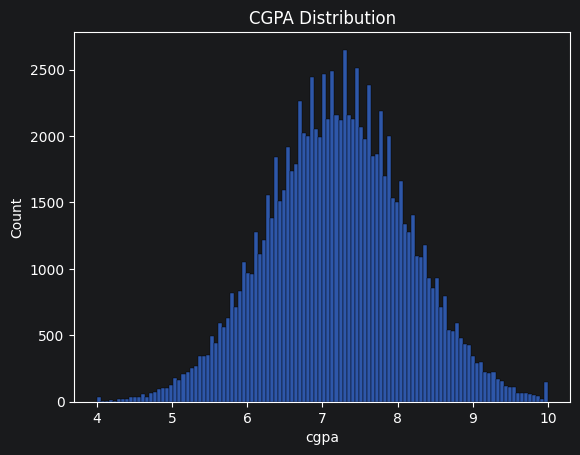

In [68]:
sns.histplot(x=df["cgpa"])
plt.title("CGPA Distribution")
plt.show()

The CGPA distribution follows a near-normal pattern, with most students concentrated between 6 and 8. This indicates that the dataset represents a moderately performing student population, with very few extreme low or high performers.

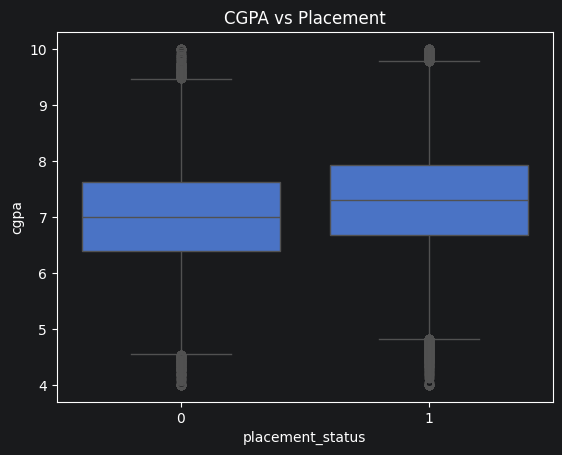

In [69]:
sns.boxplot(x=df["placement_status"], y=df["cgpa"])
plt.title("CGPA vs Placement")
plt.show()

The boxplot shows that placed students generally have a higher median CGPA compared to non-placed students, indicating a positive relationship between academic performance and placement outcomes. However, the overlap between the two groups suggests that CGPA alone is not a sufficient predictor, and other factors such as skills or internships may also play a significant role.

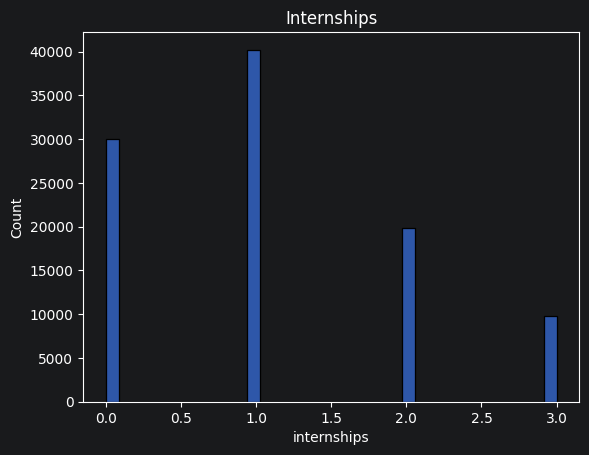

In [70]:
sns.histplot(x=df["internships"])
plt.title("Internships")
plt.show()

The majority of students have at least one internship, with a decreasing number of students as internship count increases. This indicates limited exposure to multiple internship experiences.

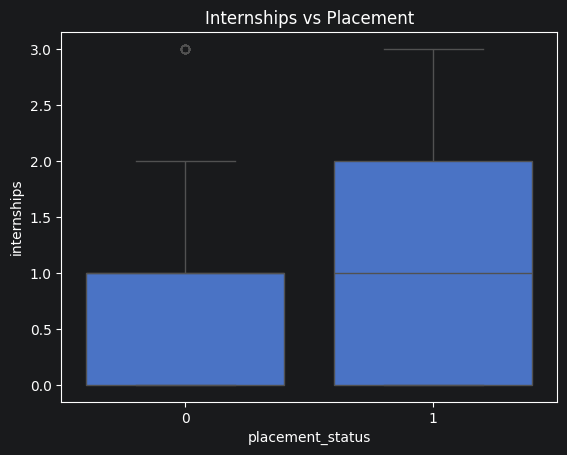

In [71]:
sns.boxplot(x=df["placement_status"], y=df["internships"])
plt.title("Internships vs Placement")
plt.show()

The analysis shows that students with internship experience have a higher likelihood of being placed. Placed students tend to have at least one internship, while non-placed students are more concentrated around zero internships. This suggests that practical experience plays a significant role in improving employability.

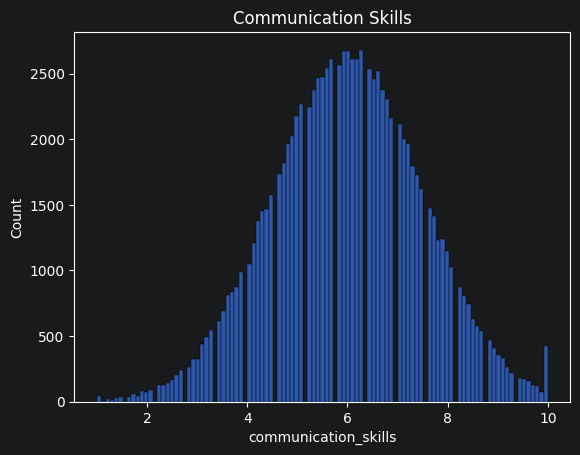

In [72]:
sns.histplot(x=df["communication_skills"])
plt.title("Communication Skills")
plt.show()

Communication skills are fairly normally distributed, with most students having moderate skill levels between 5 and 7.

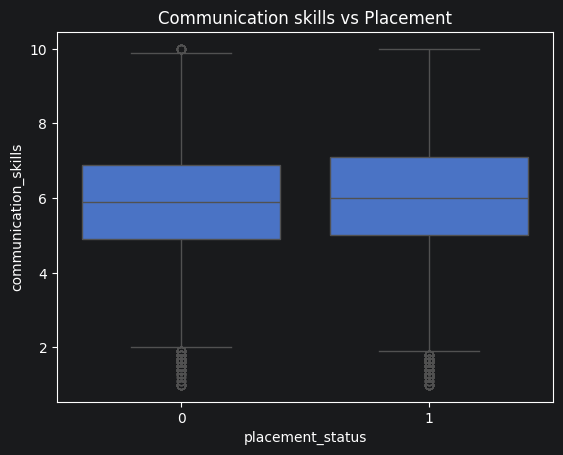

In [73]:
sns.boxplot(x=df["placement_status"], y=df["communication_skills"])
plt.title("Communication skills vs Placement")
plt.show()

Communication skills show a slight positive relationship with placement, as placed students have a marginally higher median. However, the significant overlap between the two groups indicates that communication skills alone are not a strong differentiating factor for placement outcomes.

### We are not going to analyze every single feature one by one!
- EDA is not about covering all features
- EDA is about finding the most important signals!

## 4. Data Preprocessing


- #### NO missing and duplicated since we only considered placement_status!

- #### Used Label Encoding The categorical variables `branch` and `college_tier`

- ####  Feature selection (VIF) and (RFECV)




In [74]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in x.columns:
    if x[col].dtypes == "str":
        x[col] = le.fit_transform(x[col].astype(str))

In [104]:
print(df.corr(numeric_only=True)["placement_status"])

cgpa                         0.148932
backlogs                    -0.058815
coding_skills                0.087657
dsa_score                    0.086594
aptitude_score               0.045146
communication_skills         0.051034
ml_knowledge                 0.002097
system_design               -0.001583
internships                  0.099967
projects_count               0.069900
certifications               0.055636
hackathons                   0.033315
open_source_contributions    0.022723
extracurriculars            -0.004807
placement_status             1.000000
salary_package_lpa                NaN
Name: placement_status, dtype: float64


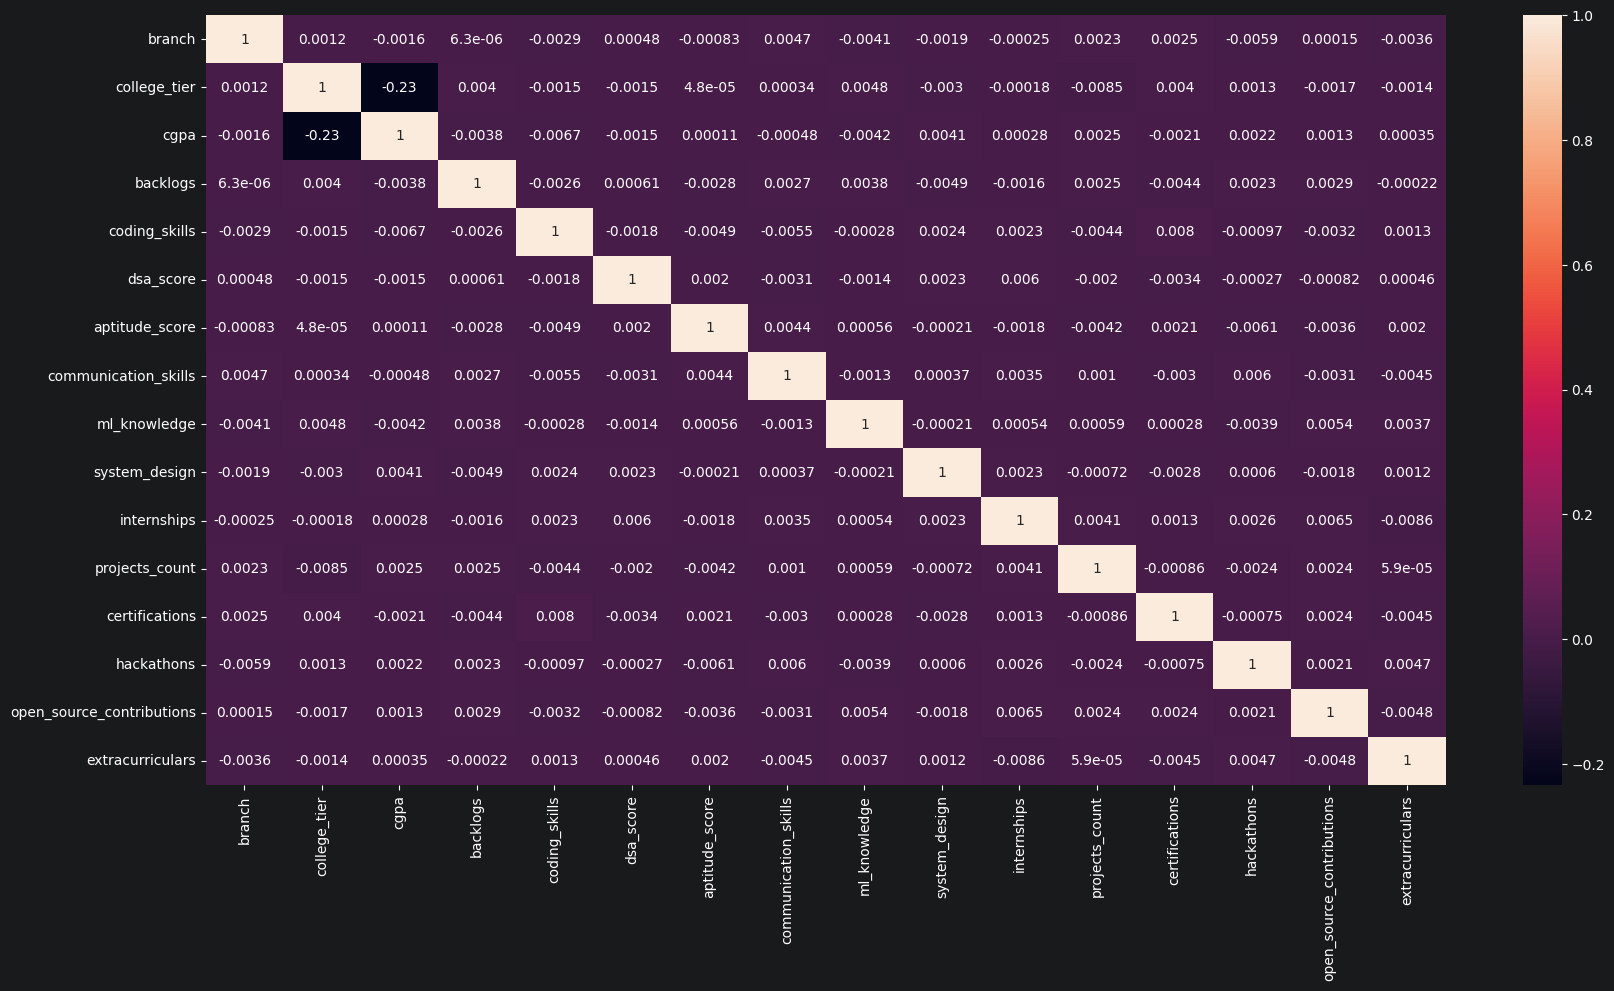

In [76]:
plt.figure(figsize = (20, 10))
sns.heatmap(x.corr(), annot=True, cmap="rocket")
plt.show()

## 5. Here we train and test model without VIF and RFECV
#### Then compare which phase is good one or two?

In [77]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

#### PIPELINE HAS USED!!!

In [78]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
model_lr = LogisticRegression()
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model_lr', LogisticRegression(class_weight="balanced", C=10, max_iter=10000))
])

pipeline.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model_lr', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",10
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not 

In [79]:
y_prob = pipeline.predict_proba(x_test)[:,1]
y_prob

array([0.56733909, 0.81600437, 0.36011005, ..., 0.41414318, 0.55155967,
       0.67720548], shape=(20000,))

In [80]:
y_pred = pipeline.predict(x_test)
y_pred

array([1, 1, 0, ..., 0, 1, 1], shape=(20000,))

In [81]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.44      0.65      0.53      6335
           1       0.79      0.62      0.70     13665

    accuracy                           0.63     20000
   macro avg       0.62      0.64      0.61     20000
weighted avg       0.68      0.63      0.64     20000



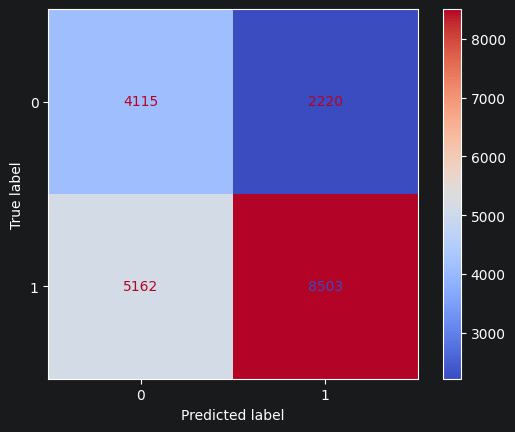

In [82]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='coolwarm')
plt.show()

## 6. VIF used for features selection!

In [83]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data["features"] = x.columns
vif_data["vif"] = [
    variance_inflation_factor(x.values, i)
    for i in range(x.shape[1])
]
vif_data.sort_values(by="vif", ascending=False, inplace=True)
vif_data


,features,vif
2,cgpa,37.619747
6,aptitude_score,25.117779
7,communication_skills,15.420088
4,coding_skills,15.353275
5,dsa_score,9.930017
8,ml_knowledge,6.051708
9,system_design,5.904003
11,projects_count,4.613150
1,college_tier,4.207098
0,branch,3.153675


In [84]:
x.drop(["cgpa"], axis=1, inplace=True)

In [85]:
vif_data = pd.DataFrame()
vif_data["features"] = x.columns
vif_data["vif"] = [
    variance_inflation_factor(x.values, i)
    for i in range(x.shape[1])
]
vif_data.sort_values(by="vif", ascending=False, inplace=True)
vif_data

,features,vif
5,aptitude_score,21.250254
6,communication_skills,14.245837
3,coding_skills,14.189269
4,dsa_score,9.500662
7,ml_knowledge,5.915355
8,system_design,5.766411
10,projects_count,4.532912
1,college_tier,4.190541
0,branch,3.123676
11,certifications,2.762486


In [86]:
x.drop(["aptitude_score"], axis=1, inplace=True)

In [87]:
vif_data = pd.DataFrame()
vif_data["features"] = x.columns
vif_data["vif"] = [
    variance_inflation_factor(x.values, i)
    for i in range(x.shape[1])
]
vif_data.sort_values(by="vif", ascending=False, inplace=True)
vif_data

,features,vif
3,coding_skills,13.011055
5,communication_skills,13.002504
4,dsa_score,9.047948
6,ml_knowledge,5.771089
7,system_design,5.632067
9,projects_count,4.458086
1,college_tier,4.126079
0,branch,3.093249
10,certifications,2.739535
13,extracurriculars,2.370698


In [88]:
x.drop(["coding_skills"], axis=1, inplace=True)


In [89]:
vif_data = pd.DataFrame()
vif_data["features"] = x.columns
vif_data["vif"] = [
    variance_inflation_factor(x.values, i)
    for i in range(x.shape[1])
]
vif_data.sort_values(by="vif", ascending=False, inplace=True)
vif_data

,features,vif
4,communication_skills,11.808934
3,dsa_score,8.596391
5,ml_knowledge,5.623395
6,system_design,5.487648
8,projects_count,4.382410
1,college_tier,4.061300
0,branch,3.063334
9,certifications,2.711844
12,extracurriculars,2.353893
7,internships,2.300222


In [90]:
x.drop(["communication_skills"], axis=1, inplace=True)

In [91]:
vif_data = pd.DataFrame()
vif_data["features"] = x.columns
vif_data["vif"] = [
    variance_inflation_factor(x.values, i)
    for i in range(x.shape[1])
]
vif_data.sort_values(by="vif", ascending=False, inplace=True)
print(vif_data["features"])

3                     dsa_score
4                  ml_knowledge
5                 system_design
7                projects_count
1                  college_tier
0                        branch
8                certifications
11             extracurriculars
6                   internships
9                    hackathons
10    open_source_contributions
2                      backlogs
Name: features, dtype: str


### VIF selected columns are,
- dsa_score
- ml_knowledge
- system_design
- projects_count
- college_tier
- branch
- certifications
- extracurriculars
- internships
- hackathons
- open_source_contributions
- backlogs

In [92]:
df

,branch,college_tier,cgpa,backlogs,coding_skills,dsa_score,aptitude_score,communication_skills,ml_knowledge,system_design,internships,projects_count,certifications,hackathons,open_source_contributions,extracurriculars,placement_status,salary_package_lpa
0,ECE,Tier-3,6.70,0,7.6,4.4,49.5,3.7,6.4,0.3,1,4,4,3,2,1,1,14.75
1,Chemical,Tier-2,5.70,0,5.4,7.9,72.0,8.3,6.3,1.9,0,4,0,0,0,0,0,NaN
2,EE,Tier-2,7.19,0,5.6,6.8,79.1,7.4,4.4,5.2,1,3,2,1,2,0,1,19.06
3,CE,Tier-2,6.48,0,5.2,3.1,48.4,5.0,1.1,6.7,1,4,3,0,0,0,0,NaN
4,CSE,Tier-2,6.71,1,5.9,4.7,61.2,4.3,2.7,2.8,1,2,0,3,0,1,1,13.42
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,IT,Tier-3,6.08,0,3.1,5.4,67.4,4.3,9.1,3.8,2,3,2,0,0,3,0,NaN
99996,IT,Tier-3,7.46,0,4.8,6.8,59.5,7.6,5.6,2.4,1,2,3,0,1,0,1,16.58
99997,EE,Tier-2,7.94,0,4.9,9.1,55.1,6.1,3.5,5.2,0,2,1,0,1,2,1,17.24
99998,ME,Tier-3,6.63,0,5.0,8.0,65.0,5.7,6.2,0.2,1,4,2,0,0,1,1,17.01


In [93]:
x1 = df.iloc[:,:-2]
x1

,branch,college_tier,cgpa,backlogs,coding_skills,dsa_score,aptitude_score,communication_skills,ml_knowledge,system_design,internships,projects_count,certifications,hackathons,open_source_contributions,extracurriculars
0,ECE,Tier-3,6.70,0,7.6,4.4,49.5,3.7,6.4,0.3,1,4,4,3,2,1
1,Chemical,Tier-2,5.70,0,5.4,7.9,72.0,8.3,6.3,1.9,0,4,0,0,0,0
2,EE,Tier-2,7.19,0,5.6,6.8,79.1,7.4,4.4,5.2,1,3,2,1,2,0
3,CE,Tier-2,6.48,0,5.2,3.1,48.4,5.0,1.1,6.7,1,4,3,0,0,0
4,CSE,Tier-2,6.71,1,5.9,4.7,61.2,4.3,2.7,2.8,1,2,0,3,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,IT,Tier-3,6.08,0,3.1,5.4,67.4,4.3,9.1,3.8,2,3,2,0,0,3
99996,IT,Tier-3,7.46,0,4.8,6.8,59.5,7.6,5.6,2.4,1,2,3,0,1,0
99997,EE,Tier-2,7.94,0,4.9,9.1,55.1,6.1,3.5,5.2,0,2,1,0,1,2
99998,ME,Tier-3,6.63,0,5.0,8.0,65.0,5.7,6.2,0.2,1,4,2,0,0,1


In [94]:
for col in x1.columns:
    if df[col].dtypes == "str":
        x1[col] = le.fit_transform(x1[col])

In [95]:
y_reg = df["salary_package_lpa"]
y_cal = df["placement_status"]
y_cal

0        1
1        0
2        1
3        0
4        1
        ..
99995    0
99996    1
99997    1
99998    1
99999    1
Name: placement_status, Length: 100000, dtype: int64

In [96]:
from sklearn.model_selection import train_test_split
x1_train, x1_test, y_train, y_test = train_test_split(x1, y, test_size=0.2, random_state=42)

In [97]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
le1 = LabelEncoder()


model_lr = LogisticRegression()
pipeline1 = Pipeline([
    ('scaler', StandardScaler()),
    ('model_lr', LogisticRegression(class_weight="balanced", max_iter=10000, C=10))
])

pipeline1.fit(x1_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model_lr', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",10
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not 

In [98]:
y1_pred = pipeline1.predict(x1_test)
y1_pred

array([1, 1, 0, ..., 0, 1, 1], shape=(20000,))

In [99]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y1_pred))

              precision    recall  f1-score   support

           0       0.44      0.65      0.53      6335
           1       0.79      0.62      0.70     13665

    accuracy                           0.63     20000
   macro avg       0.62      0.64      0.61     20000
weighted avg       0.68      0.63      0.64     20000



### For "placement_status" we summon multiple models for comparison between Logistic and trees based model which act well!?


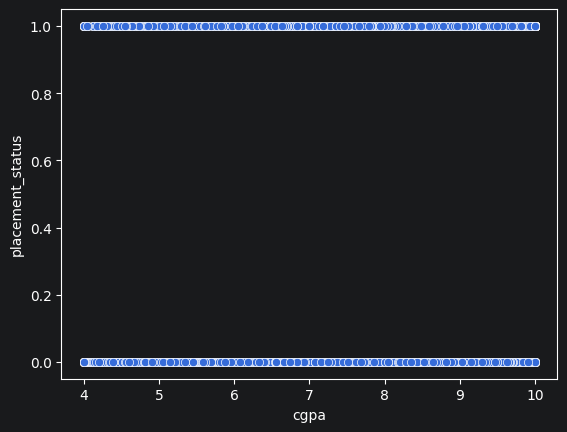

In [100]:
sns.scatterplot(x=df["cgpa"], y= y_cal)
plt.show()

## 7. Model Training with RFECV Check!

Three machine learning algorithms were used to predict student placement outcomes:

### Logistic Regression
A linear classification model commonly used as a baseline for binary prediction problems.

### Decision Tree Classifier
A tree-based model capable of capturing non-linear relationships between features.

### Random Forest Classifier
An ensemble learning algorithm that combines multiple decision trees to improve prediction stability and reduce overfitting.

Each model was trained using the processed dataset and evaluated using classification metrics.

In [101]:
from sklearn.model_selection import train_test_split
x1_train, x1_test, y_cal_train, y_cal_test = train_test_split(x1, y_cal, test_size=0.2, random_state=42)

from sklearn.feature_selection import RFECV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

lr = LogisticRegression(max_iter=10000, class_weight="balanced", C=0.1) # because of class imbalance
rfecv1 = RFECV(lr)
rfecv1.fit(x1_train, y_cal_train)

print(rfecv1.support_)
print(rfecv1.ranking_)

[ True  True  True  True  True  True  True  True False  True  True  True
  True  True  True  True]
[1 1 1 1 1 1 1 1 2 1 1 1 1 1 1 1]


In [102]:
dt = DecisionTreeClassifier(max_depth=5)
rfecv2 = RFECV(dt)
rfecv2.fit(x1_train, y_cal_train)

print(rfecv2.support_)
print(rfecv2.ranking_)

[False  True  True False  True  True False False False False  True False
 False False False False]
[12  1  1  4  1  1  3  6 11 10  1  5  2  9  8  7]


In [103]:
rf = RandomForestClassifier(max_depth=5)
rfecv3 = RFECV(rf)
rfecv3.fit(x1_train, y_cal_train)

print(rfecv3.support_)
print(rfecv3.ranking_)

KeyboardInterrupt: 

#### We used all feature, since literally entier features have prediction signals

In [ ]:
x1_train, x1_test, y_cal_train, y_cal_test = train_test_split(x1, y_cal, test_size=0.2, random_state=42)

In [ ]:
rf.fit(x1_train, y_cal_train)

In [ ]:
dt.fit(x1_train, y_cal_train)

In [ ]:
lr.fit(x1_train, y_cal_train)

In [ ]:
y_pred_lr_cal = lr.predict(x1_test)
y_pred_lr_cal

In [ ]:
y_pred_dt_cal = dt.predict(x1_test)
y_pred_dt_cal

In [ ]:
y_pred_rf_cal = rf.predict(x1_test)
y_pred_rf_cal

## 8. Model Comparison

The performance of the trained models was compared using classification metrics such as accuracy, precision, recall, and F1-score.


In [ ]:
from sklearn.metrics import classification_report # class_weights = balanced else accuracy might 70
print(classification_report(y_cal_test, y_pred_lr_cal))

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_cal_test, y_pred_dt_cal))

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_cal_test, y_pred_rf_cal))

| Model         | Accuracy | Recall(0) | Recall(1) | Verdict    |
| ------------- | -------- | --------- | --------- | ---------- |
| Logistic      | 0.63     | **0.65**  | 0.62      |  Best      |
| Decision Tree | 0.69     | 0.07      | 0.98      |  Biased    |
| Random Forest | 0.69     | 0.01      | 1.00      |  Very biased |


**Logistic Regression achieved lower overall accuracy (~63%) but maintained balanced recall across both classes. This indicates that the model is able to detect both placed and non-placed students more reliably.**

For this reason, Logistic Regression was selected as the final model for this project.

In [ ]:
import shap

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(x1_train)
plt.figure(figsize=(20,5))
shap.summary_plot(shap_values, x1_train)
plt.show()

In [ ]:
import joblib as jb

jb.dump(lr, "placement_model.pkl")